In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")

In [4]:
# Load the dataset
df = pd.read_csv('boston.csv').copy()
target_col = 'MEDV' # Standard target name for Boston Housing

print(f'Shape: {df.shape}')
print('\nFirst 5 rows:')
print(df.head())

print('\nData Types:')
print(df.dtypes)

print('\nSummary Statistics:')
print(df.describe().T)

print(f'\nDuplicate rows: {df.duplicated().sum()}')
print('\nMissing Values:')
print(df.isna().sum())

Shape: (506, 14)

First 5 rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Data Types:
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

Summary Statistics:
         co

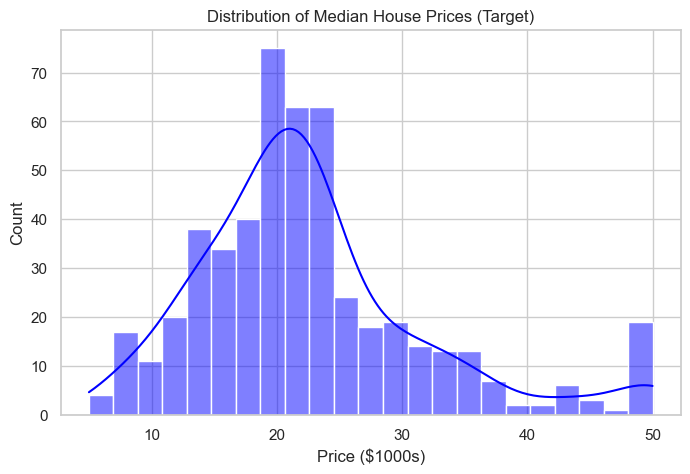

In [5]:
# Since this is regression, we look at the distribution of the price
plt.figure(figsize=(8, 5))
sns.histplot(df[target_col], kde=True, color='blue')
plt.title("Distribution of Median House Prices (Target)")
plt.xlabel("Price ($1000s)")
plt.show()

In [6]:
# Handling missing values and numeric conversion
for col in df.columns:
    if col != target_col:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

X = df.drop(target_col, axis=1)
y = df[target_col]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA to explain 95% of variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print(f"Original features: {X.shape[1]}")
print(f"Reduced features (PCA): {X_pca.shape[1]}")

# Split - No 'stratify' here because 'y' is continuous (regression)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

Original features: 13
Reduced features (PCA): 9


In [7]:
# Regression specific models
models = [
    ('LinearRegression', GridSearchCV(LinearRegression(), {}, cv=5)),
    ('Ridge', GridSearchCV(Ridge(), {'alpha': [0.1, 1.0, 10.0]}, cv=5)),
    ('RandomForest', GridSearchCV(RandomForestRegressor(), {'n_estimators': [50, 100]}, cv=3))
]

results = []

for name, grid in models:
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    # Using R2 Score (Accuracy for regression) and MAE
    results.append({
        'Model': name,
        'Best Params': grid.best_params_,
        'CV Best R2': round(grid.best_score_, 4),
        'Test R2': round(r2_score(y_test, y_pred), 4),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4)
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Test R2', ascending=False).reset_index(drop=True)

print("Model Comparison Results:")
print(results_df)

print(f"\nBest model: {results_df.loc[0, 'Model']}")

Model Comparison Results:
              Model           Best Params  CV Best R2  Test R2     MAE
0      RandomForest  {'n_estimators': 50}      0.7560   0.7873  2.3028
1             Ridge       {'alpha': 10.0}      0.7028   0.6021  3.3215
2  LinearRegression                    {}      0.7018   0.5976  3.3410

Best model: RandomForest
